# Lecture 12 · Character-level RNN language model

**Goal** · train a small from-scratch RNN on the same tiny name list and generate new names, contrasting with the fixed-context MLP of Lecture 11. The RNN carries a hidden state instead of a fixed window.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

## 1 · Data: names as padded character sequences

Each name becomes `.` + name + `.`, padded to a common length. Input is the sequence, target is the sequence shifted by one (predict the next character).

In [2]:
names = ["emma","olivia","ava","isabella","sophia","mia","charlotte","amelia",
         "harper","evelyn","abigail","emily","ella","elizabeth","camila","luna",
         "sofia","avery","mila","aria","scarlett","penelope","layla","chloe",
         "victoria","riley","aurora","nora","hazel","lily","ellie","grace"]
chars = ['.'] + sorted(set(''.join(names)))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
V = len(chars)

T = max(len(w) for w in names) + 2
seqs = []
for w in names:
    s = '.' + w + '.'
    s = s + '.' * (T - len(s))          # pad with stop token
    seqs.append([stoi[c] for c in s])
S = torch.tensor(seqs)
Xin, Ytar = S[:, :-1], S[:, 1:]
print(f'{len(names)} names, V={V}, padded length T={T}')
print('inputs:', tuple(Xin.shape), ' targets:', tuple(Ytar.shape))

32 names, V=21, padded length T=11
inputs: (32, 10)  targets: (32, 10)


## 2 · A vanilla RNN cell from scratch

$h_t=\tanh(W_{xh}e_t+W_{hh}h_{t-1})$, shared across time; a linear head maps $h_t$ to next-char logits.

In [3]:
m = 32          # hidden size
de = 16         # embedding size
class CharRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, de)
        self.Wxh = nn.Linear(de, m, bias=False)
        self.Whh = nn.Linear(m, m, bias=True)
        self.Why = nn.Linear(m, V)
    def forward(self, x):
        B, L = x.shape
        h = torch.zeros(B, m)
        logits = []
        for t in range(L):
            e = self.emb(x[:, t])
            h = torch.tanh(self.Wxh(e) + self.Whh(h))   # shared cell each step
            logits.append(self.Why(h))
        return torch.stack(logits, dim=1)               # (B, L, V)

model = CharRNN()
print('parameters:', sum(p.numel() for p in model.parameters()))

parameters: 2597


## 3 · Train (BPTT over the unrolled sequence)

final loss: 0.352


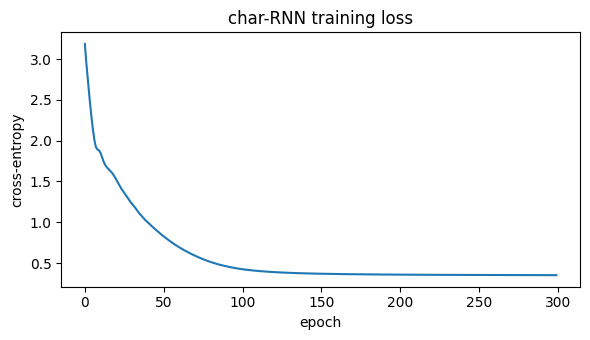

In [4]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
hist = []
for epoch in range(300):
    logits = model(Xin)                                 # (B, L, V)
    loss = F.cross_entropy(logits.reshape(-1, V), Ytar.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # tame exploding grads
    opt.step(); hist.append(loss.item())
print('final loss:', round(hist[-1], 3))
plt.figure(figsize=(6, 3.5)); plt.plot(hist)
plt.xlabel('epoch'); plt.ylabel('cross-entropy'); plt.title('char-RNN training loss')
plt.tight_layout(); plt.show()

## 4 · Generate names

Feed the start token `.`, carry the hidden state forward one character at a time, sample with temperature, and stop at `.`.

In [5]:
@torch.no_grad()
def generate(temp=0.8, max_len=15):
    h = torch.zeros(1, m)
    ix = 0            # '.'
    out = []
    for _ in range(max_len):
        e = model.emb(torch.tensor([ix]))
        h = torch.tanh(model.Wxh(e) + model.Whh(h))
        p = F.softmax(model.Why(h) / temp, dim=1)
        ix = torch.multinomial(p, 1).item()
        if ix == 0:
            break
        out.append(itos[ix])
    return ''.join(out)

torch.manual_seed(2)
print('sampled names:')
for _ in range(10):
    print('  ', generate())

sampled names:
   avery
   ella
   scarlett
   chloe
   layla
   isabella
   abigail
   avery
   layla
   emily


## Takeaway

- The RNN reuses one cell across time and carries a hidden state — variable length, shared parameters.
- Training is BPTT through the unrolled loop; gradient clipping guards against explosions.
- Unlike the fixed-$k$ MLP, the state can in principle summarise arbitrarily long context (subject to vanishing).